# Exploratory Data Analysis with Visualizations

Objective: Learn to explore datasets using pandas and create informative visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load Titanic dataset
df = pd.read_csv('titanic.csv')

In [3]:
# 1. Basic exploration
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn data types:")
print(df.dtypes)

Dataset shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                              Heikkinen, Miss Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

In [4]:
# 2. Missing data analysis
print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0])


Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [5]:
# 3. Summary statistics by group
print("\nAge statistics by class:")
age_by_class = df.groupby('Pclass')['Age'].describe()
print(age_by_class)


Age statistics by class:
        count       mean        std   min   25%   50%   75%   max
Pclass                                                           
1       186.0  38.233441  14.802856  0.92  27.0  37.0  49.0  80.0
2       173.0  29.877630  14.001077  0.67  23.0  29.0  36.0  70.0
3       355.0  25.140620  12.495398  0.42  18.0  24.0  32.0  74.0


In [6]:
# 4. Survival analysis
overall_survival = df['Survived'].mean()
print(f"\nOverall survival rate: {overall_survival:.2%}")

survival_by_class = df.groupby('Pclass')['Survived'].agg([
    ('count', 'count'),
    ('survived', 'sum'),
    ('survival_rate', 'mean')
])
print("\nSurvival by class:")
print(survival_by_class)


Overall survival rate: 38.38%

Survival by class:
        count  survived  survival_rate
Pclass                                
1         216       136       0.629630
2         184        87       0.472826
3         491       119       0.242363


In [7]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print("\nSurvival by sex:")
print(survival_by_sex)


Survival by sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


### VISUALIZATIONS (4 plots)

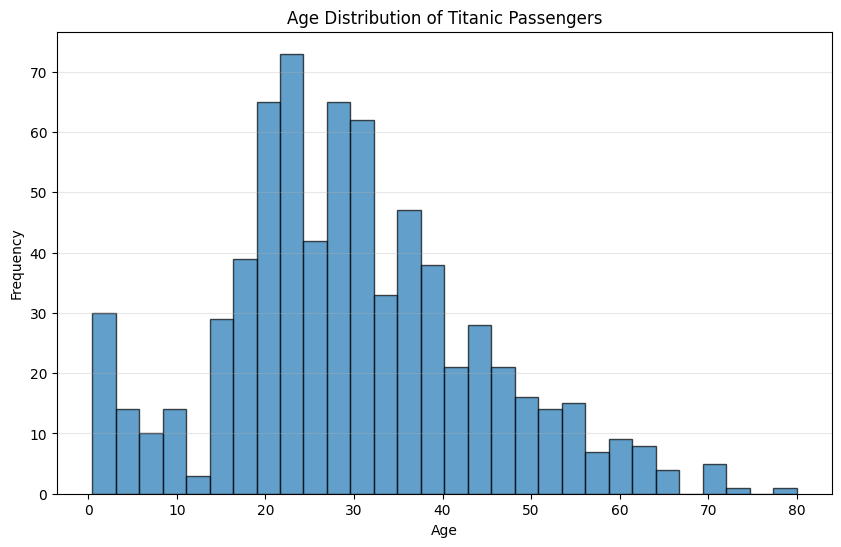

In [8]:
# Plot 1: Age distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Age'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of Titanic Passengers')
plt.grid(axis='y', alpha=0.3)
plt.show()

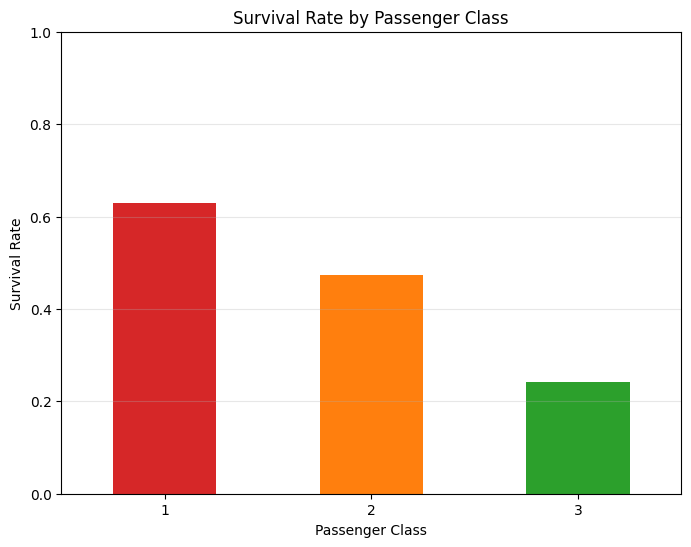

In [9]:
# Plot 2: Survival rate by class
plt.figure(figsize=(8, 6))
survival_by_class['survival_rate'].plot(kind='bar', color=['#d62728', '#ff7f0e', '#2ca02c'])
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Passenger Class')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

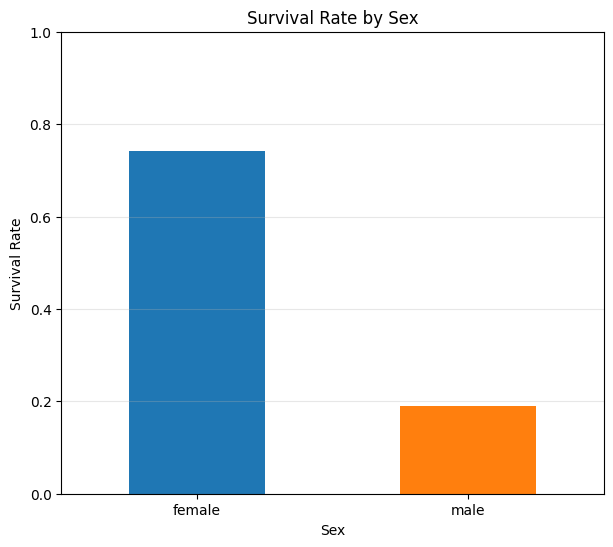

In [10]:
# Plot 3: Survival rate by sex
plt.figure(figsize=(7, 6))
survival_by_sex.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Sex')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

/var/folders/zm/4sych_z962dd2wflldz8mxtr0000gn/T/ipykernel_4054/1394483244.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([died_ages, survived_ages], labels=['Died', 'Survived'])


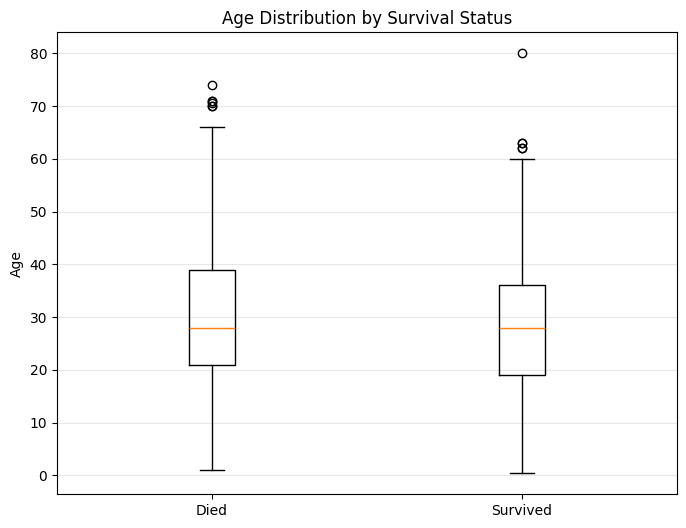

In [11]:
# Plot 4: Age distribution by survival (box plot)
plt.figure(figsize=(8, 6))
survived_ages = df[df['Survived'] == 1]['Age'].dropna()
died_ages = df[df['Survived'] == 0]['Age'].dropna()
plt.boxplot([died_ages, survived_ages], labels=['Died', 'Survived'])
plt.ylabel('Age')
plt.title('Age Distribution by Survival Status')
plt.grid(axis='y', alpha=0.3)
plt.show()

---------------

# Feature Engineering with NumPy and Visualization


Objective: Create new features using NumPy operations and visualize their relationships with survival.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

In [13]:
# 1. Create age groups using numpy.digitize
df_clean = df[df['Age'].notna()].copy()
age_bins = np.array([0, 12, 18, 35, 60, 100])
age_groups = np.digitize(df_clean['Age'].values, age_bins)

# Map to labels
label_mapping = {1: 'Child', 2: 'Teen', 3: 'Adult', 4: 'Middle-aged', 5: 'Senior'}
df_clean['Age_Group'] = pd.Series(age_groups).map(label_mapping)

print("Age group distribution:")
print(df_clean['Age_Group'].value_counts().sort_index())

Age group distribution:
Age_Group
Adult          292
Child           58
Middle-aged    159
Senior          23
Teen            35
Name: count, dtype: int64


In [14]:
# 2. Survival rate by age group
survival_by_age = df_clean.groupby('Age_Group')['Survived'].agg([
    ('count', 'count'),
    ('survival_rate', 'mean')
])
# Reorder properly
order = ['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior']
survival_by_age = survival_by_age.reindex(order)
print("\nSurvival by age group:")
print(survival_by_age)


Survival by age group:
             count  survival_rate
Age_Group                        
Child           58       0.344828
Teen            35       0.457143
Adult          292       0.410959
Middle-aged    159       0.433962
Senior          23       0.304348


In [15]:
# 3. Create family size feature using numpy
df_clean['Family_Size'] = df_clean['SibSp'] + df_clean['Parch'] + 1

print("\nFamily size statistics:")
family_stats = df_clean.groupby('Family_Size')['Survived'].agg([
    ('count', 'count'),
    ('survival_rate', 'mean')
])
print(family_stats)


Family size statistics:
             count  survival_rate
Family_Size                      
1              404       0.321782
2              139       0.546763
3               93       0.569892
4               27       0.777778
5               11       0.272727
6               22       0.136364
7               12       0.333333
8                6       0.000000


In [16]:
# 4. Fare per person
df_clean['Fare_Per_Person'] = df_clean['Fare'] / df_clean['Family_Size']

print(f"\nAverage fare: ${df_clean['Fare'].mean():.2f}")
print(f"Average fare per person: ${df_clean['Fare_Per_Person'].mean():.2f}")


Average fare: $34.69
Average fare per person: $20.90


### VISUALIZATIONS (4 plots)

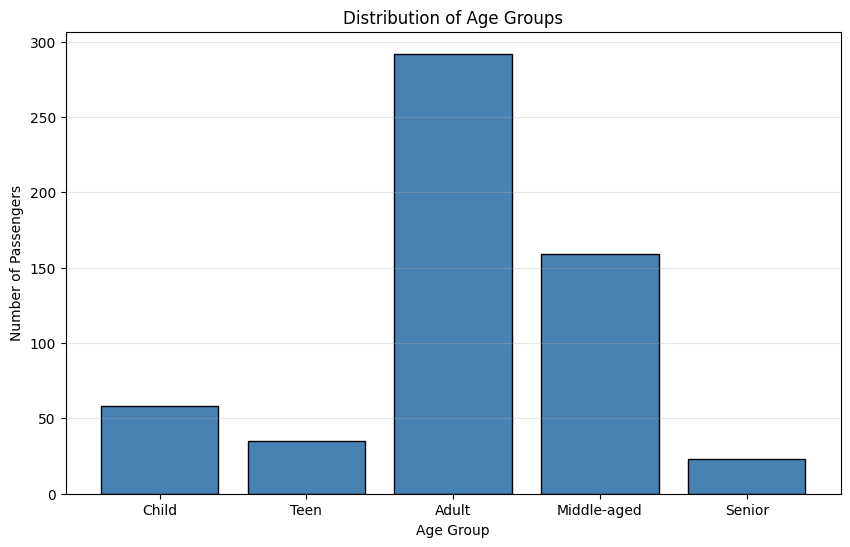

In [17]:
# Plot 1: Age group distribution
plt.figure(figsize=(10, 6))
age_counts = df_clean['Age_Group'].value_counts().reindex(order)
plt.bar(age_counts.index, age_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')
plt.title('Distribution of Age Groups')
plt.grid(axis='y', alpha=0.3)
plt.show()

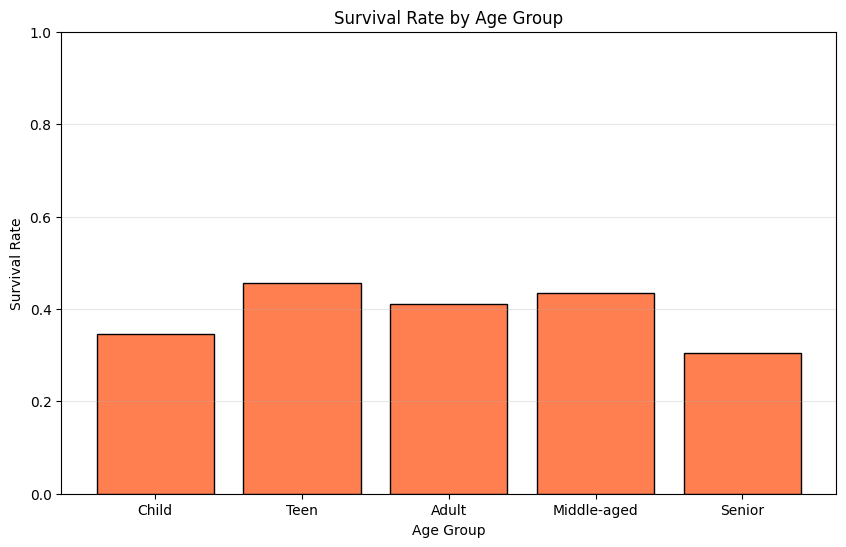

In [18]:
# Plot 2: Survival rate by age group
plt.figure(figsize=(10, 6))
plt.bar(survival_by_age.index, survival_by_age['survival_rate'], 
        color='coral', edgecolor='black')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Age Group')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

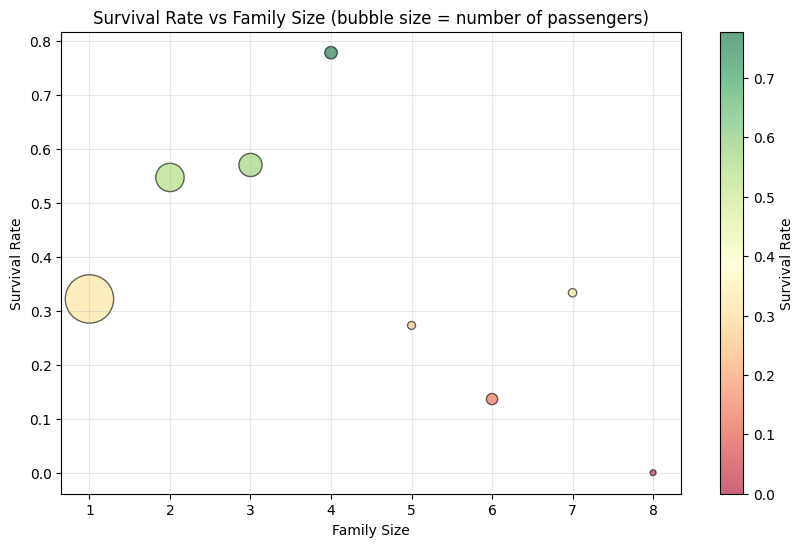

In [19]:
# Plot 3: Family size vs survival
plt.figure(figsize=(10, 6))
plt.scatter(family_stats.index, family_stats['survival_rate'], 
            s=family_stats['count']*3, alpha=0.6, c=family_stats['survival_rate'],
            cmap='RdYlGn', edgecolors='black')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.title('Survival Rate vs Family Size (bubble size = number of passengers)')
plt.colorbar(label='Survival Rate')
plt.grid(alpha=0.3)
plt.show()

/var/folders/zm/4sych_z962dd2wflldz8mxtr0000gn/T/ipykernel_4054/1180691878.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(fare_by_class, labels=['1st Class', '2nd Class', '3rd Class'])


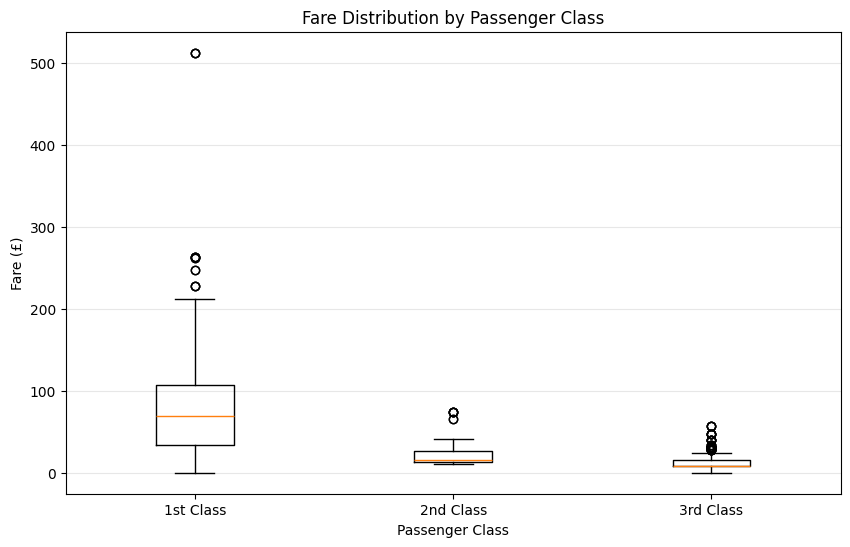

In [20]:
# Plot 4: Fare distribution by class (box plot)
plt.figure(figsize=(10, 6))
fare_by_class = [df_clean[df_clean['Pclass']==i]['Fare'].dropna() for i in [1,2,3]]
plt.boxplot(fare_by_class, labels=['1st Class', '2nd Class', '3rd Class'])
plt.ylabel('Fare (£)')
plt.xlabel('Passenger Class')
plt.title('Fare Distribution by Passenger Class')
plt.grid(axis='y', alpha=0.3)
plt.show()

------------------

# Correlation Analysis and Pivot Tables

Objective: Understand feature relationships using correlation and pivot tables with visualizations.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('titanic.csv')

In [22]:
# 1. Correlation matrix using numpy
df_numeric = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].dropna()

# Calculate correlation using numpy
corr_matrix = np.corrcoef(df_numeric.T)
columns = df_numeric.columns.tolist()
corr_df = pd.DataFrame(corr_matrix, index=columns, columns=columns)

print("Correlation Matrix:")
print(corr_df.round(3))

Correlation Matrix:
          Survived  Pclass    Age  SibSp  Parch   Fare
Survived     1.000  -0.360 -0.077 -0.017  0.093  0.268
Pclass      -0.360   1.000 -0.369  0.067  0.026 -0.554
Age         -0.077  -0.369  1.000 -0.308 -0.189  0.096
SibSp       -0.017   0.067 -0.308  1.000  0.384  0.138
Parch        0.093   0.026 -0.189  0.384  1.000  0.205
Fare         0.268  -0.554  0.096  0.138  0.205  1.000


In [23]:
# 2. Features most correlated with survival
print("\nCorrelations with Survived:")
corr_with_survived = corr_df['Survived'].sort_values(ascending=False)
print(corr_with_survived)


Correlations with Survived:
Survived    1.000000
Fare        0.268189
Parch       0.093317
SibSp      -0.017358
Age        -0.077221
Pclass     -0.359653
Name: Survived, dtype: float64


In [24]:
# 3. Pivot table: Survival by Class and Sex
pivot = pd.pivot_table(
    df,
    values='Survived',
    index='Pclass',
    columns='Sex',
    aggfunc=['mean', 'count']
)
print("\nPivot Table - Survival Rate by Class and Sex:")
print(pivot)


Pivot Table - Survival Rate by Class and Sex:
            mean            count     
Sex       female      male female male
Pclass                                
1       0.968085  0.368852     94  122
2       0.921053  0.157407     76  108
3       0.500000  0.135447    144  347


In [25]:
# 4. Fare by class and survival
fare_pivot = pd.pivot_table(
    df,
    values='Fare',
    index='Pclass',
    columns='Survived',
    aggfunc='mean'
)
print("\nAverage Fare by Class and Survival:")
print(fare_pivot)


Average Fare by Class and Survival:
Survived          0          1
Pclass                        
1         64.684007  95.608029
2         19.412328  22.055700
3         13.669364  13.694887


### VISUALIZATIONS (4 plots)

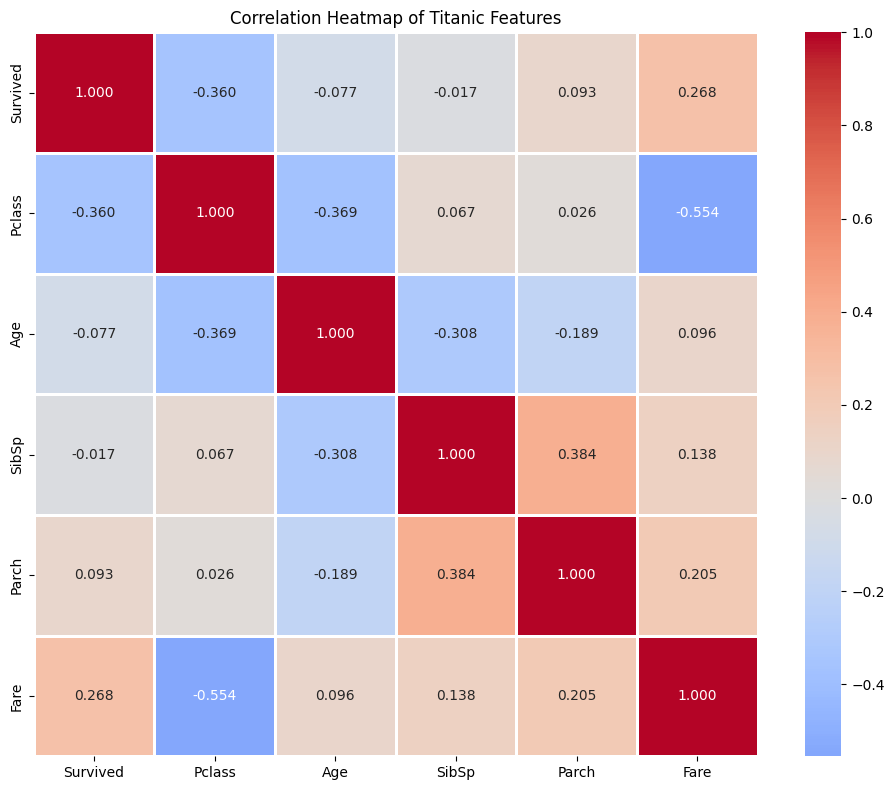

In [26]:
# Plot 1: Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.3f')
plt.title('Correlation Heatmap of Titanic Features')
plt.tight_layout()
plt.show()

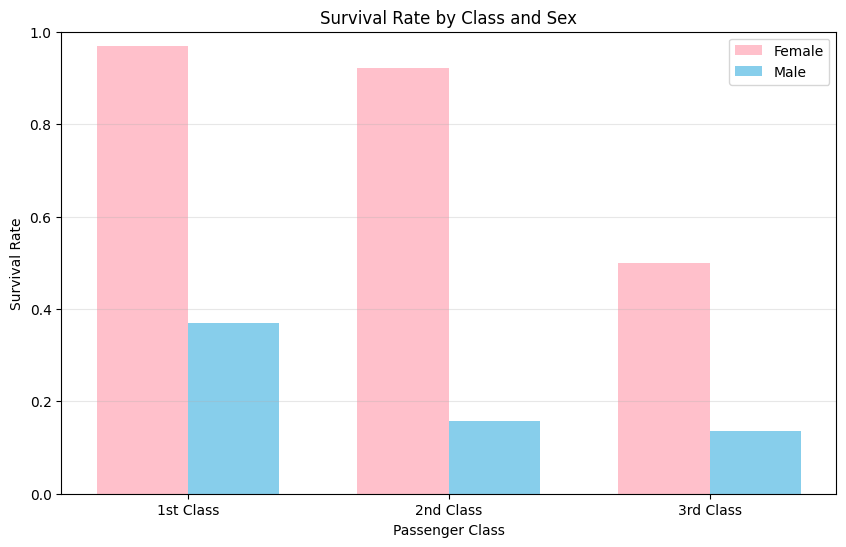

In [27]:
# Plot 2: Survival rate by class and sex (grouped bar)
plt.figure(figsize=(10, 6))
survival_data = pivot['mean']
x = np.arange(len(survival_data.index))
width = 0.35

plt.bar(x - width/2, survival_data['female'], width, label='Female', color='pink')
plt.bar(x + width/2, survival_data['male'], width, label='Male', color='skyblue')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Class and Sex')
plt.xticks(x, ['1st Class', '2nd Class', '3rd Class'])
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

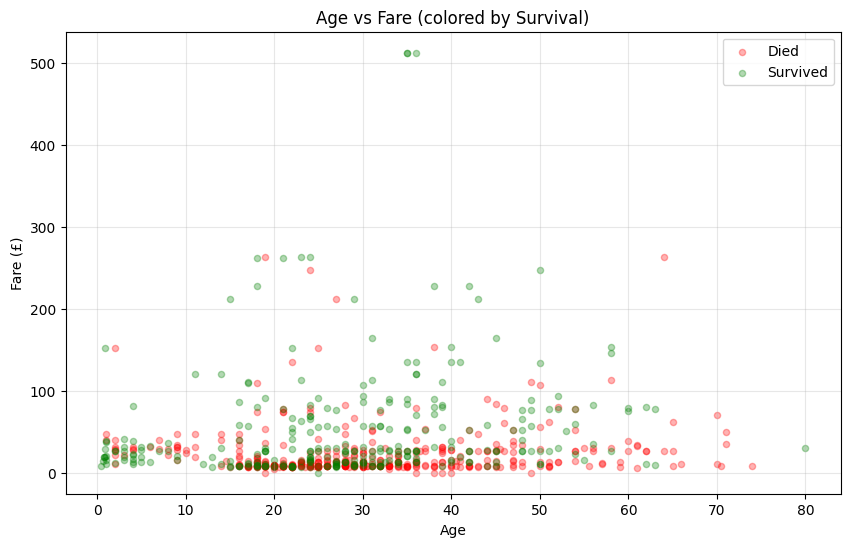

In [28]:
# Plot 3: Age vs Fare scatter colored by survival
plt.figure(figsize=(10, 6))
survived = df[df['Survived'] == 1]
died = df[df['Survived'] == 0]

plt.scatter(died['Age'], died['Fare'], c='red', alpha=0.3, s=20, label='Died')
plt.scatter(survived['Age'], survived['Fare'], c='green', alpha=0.3, s=20, label='Survived')
plt.xlabel('Age')
plt.ylabel('Fare (£)')
plt.title('Age vs Fare (colored by Survival)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

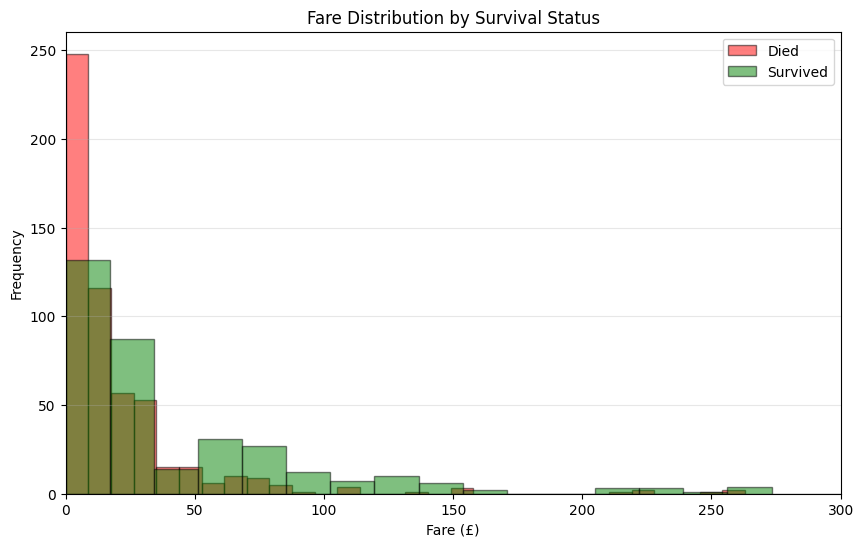

In [29]:
# Plot 4: Fare distribution by survival
plt.figure(figsize=(10, 6))
survived_fare = df[df['Survived'] == 1]['Fare'].dropna()
died_fare = df[df['Survived'] == 0]['Fare'].dropna()

plt.hist(died_fare, bins=30, alpha=0.5, label='Died', color='red', edgecolor='black')
plt.hist(survived_fare, bins=30, alpha=0.5, label='Survived', color='green', edgecolor='black')
plt.xlabel('Fare (£)')
plt.ylabel('Frequency')
plt.title('Fare Distribution by Survival Status')
plt.legend()
plt.xlim(0, 300)
plt.grid(axis='y', alpha=0.3)
plt.show()